# Cervical Dystonia Detection using MediaPipe Pose Landmarks

This notebook detects abnormal head poses associated with **Cervical Dystonia** using MediaPipe's pre-trained Pose Landmarker model.

## Two conditions detected:
- **Rotational Torticollis** — head rotates/turns to one side (yaw)
- **Laterocollis** — head tilts to one side (roll)

## Five geometric features used:
| Feature | Formula | Detects |
|---|---|---|
| F1: θ_roll | angle(ear line) − angle(shoulder line) | Laterocollis |
| F2: R_ES | dist(LEar,LS) / dist(REar,RS) | Laterocollis |
| F3: Δx_nose | (nose_x − midline_x) / shoulder_width | Rotation |
| F4: R_ear | dist(nose,LEar) / dist(nose,REar) | Rotation |
| F5: θ_eye | angle(eye line) − angle(shoulder line) | Laterocollis |

## Cell 1 — Install dependencies

In [1]:
# Install MediaPipe (Kaggle has older pip; force upgrade)
!pip install -q mediapipe --upgrade

# Verify
import mediapipe
print('MediaPipe version:', mediapipe.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 72.3 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 5.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


2026-04-18 16:21:02.001826: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776529262.263853      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776529262.338343      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776529263.001841      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776529263.001910      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776529263.001913      55 computation_placer.cc:177] computation placer alr

MediaPipe version: 0.10.33


## Cell 2 — Download the pre-trained MediaPipe Pose Landmarker model

In [2]:
import urllib.request
import os

MODEL_URL = (
    'https://storage.googleapis.com/mediapipe-models/'
    'pose_landmarker/pose_landmarker_heavy/float16/latest/'
    'pose_landmarker_heavy.task'
)
MODEL_PATH = '/kaggle/working/pose_landmarker_heavy.task'

if not os.path.exists(MODEL_PATH):
    print('Downloading pose_landmarker_heavy.task ...')
    urllib.request.urlretrieve(MODEL_URL, MODEL_PATH)
    size_mb = os.path.getsize(MODEL_PATH) / 1e6
    print(f'Downloaded: {size_mb:.1f} MB')
else:
    print('Model already present.')

print('Model path:', MODEL_PATH)

Downloaded: 30.7 MB
Model path: /kaggle/working/pose_landmarker_heavy.task


## Cell 3 — Imports and data structures

In [3]:
import cv2
import math
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from dataclasses import dataclass
from pathlib import Path
import mediapipe as mp
from mediapipe.tasks.python import vision
from mediapipe.tasks.python import BaseOptions


# ── 2D landmark with pixel coordinates ──────────────────────
@dataclass
class Landmark:
    x: float
    y: float
    visibility: float = 1.0


# ── Container for the 5 features ────────────────────────────
@dataclass
class HeadPoseFeatures:
    theta_roll: float   # F1 – degrees
    R_ES:       float   # F2 – ratio
    dx_nose:    float   # F3 – fraction of shoulder width
    R_ear:      float   # F4 – ratio
    theta_eye:  float   # F5 – degrees


# MediaPipe Pose landmark indices we need
LM_IDX = {
    'nose':           0,
    'left_eye':       2,   # outer corner
    'right_eye':      5,   # outer corner
    'left_ear':       7,
    'right_ear':      8,
    'left_shoulder':  11,
    'right_shoulder': 12,
}

print('Imports OK.')

Imports OK.


## Cell 4 — Thresholds

In [4]:
# ─────────────────────────────────────────────────────────────
#  Thresholds (derived from clinical literature & feature design)
#
#  "Normal" = clearly within normal limits
#  "Borderline" = between normal and abnormal
#  "ABNORMAL" = clearly outside normal limits
# ─────────────────────────────────────────────────────────────
THRESHOLDS = {
    # F1 & F5: angle features (degrees)
    'theta_roll': {'normal': 5.0,  'abnormal': 15.0},
    'theta_eye':  {'normal': 5.0,  'abnormal': 15.0},

    # F2: ear-shoulder ratio
    'R_ES': {
        'normal_lo':   0.85, 'normal_hi':   1.15,
        'abnormal_lo': 0.60, 'abnormal_hi': 1.60,
    },

    # F3: nose offset (fraction of shoulder width)
    'dx_nose': {'normal': 0.05, 'abnormal': 0.15},

    # F4: nose-to-ear ratio
    'R_ear': {
        'normal_lo':   0.85, 'normal_hi':   1.15,
        'abnormal_lo': 0.50, 'abnormal_hi': 2.00,
    },
}

print('Thresholds set.')

Thresholds set.


## Cell 5 — Landmark extraction using MediaPipe Pose Landmarker

In [5]:
def extract_landmarks(image_bgr: np.ndarray,
                      model_path: str = MODEL_PATH
                      ) -> dict | None:
    """
    Run MediaPipe PoseLandmarker on a BGR image.

    Returns
    -------
    dict[str, Landmark]  keyed by name  OR  None if no person detected
    """
    h, w = image_bgr.shape[:2]

    options = vision.PoseLandmarkerOptions(
        base_options=BaseOptions(model_asset_path=model_path),
        num_poses=1,
        min_pose_detection_confidence=0.4,
        min_pose_presence_confidence=0.4,
        min_tracking_confidence=0.4,
    )

    # Convert BGR → RGB for MediaPipe
    rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)

    with vision.PoseLandmarker.create_from_options(options) as detector:
        result = detector.detect(mp_image)

    if not result.pose_landmarks:
        return None

    raw = result.pose_landmarks[0]   # first (only) person

    lm = {}
    for name, idx in LM_IDX.items():
        lm[name] = Landmark(
            x=raw[idx].x * w,
            y=raw[idx].y * h,
            visibility=raw[idx].visibility,
        )
    return lm


print('extract_landmarks() defined.')

extract_landmarks() defined.


## Cell 6 — Feature computation

In [7]:
# ── Geometry helpers ─────────────────────────────────────────

def dist(a: Landmark, b: Landmark) -> float:
    """Euclidean distance between two landmarks."""
    return math.hypot(a.x - b.x, a.y - b.y)


def line_angle_deg(a: Landmark, b: Landmark) -> float:
    """Angle (degrees) of the directed line a→b w.r.t. the horizontal."""
    return math.degrees(math.atan2(b.y - a.y, b.x - a.x))


# ── Feature computation ──────────────────────────────────────

def compute_features(lm: dict) -> HeadPoseFeatures:
    """
    Compute the 5 head-pose features from the 7 landmarks.

    F1  theta_roll = angle(ear line)  − angle(shoulder line)
    F2  R_ES       = dist(LEar, LS)   / dist(REar, RS)
    F3  dx_nose    = (nose_x − midline_x) / shoulder_width
    F4  R_ear      = dist(N, LEar)    / dist(N, REar)
    F5  theta_eye  = angle(eye line)  − angle(shoulder line)
    """
    N   = lm['nose']
    LE  = lm['left_eye']
    RE  = lm['right_eye']
    LEa = lm['left_ear']
    REa = lm['right_ear']
    LS  = lm['left_shoulder']
    RS  = lm['right_shoulder']

    # Shoulder width — used as normalisation constant
    W = max(dist(LS, RS), 1e-6)

    # Reference angle of shoulder line
    shoulder_angle = line_angle_deg(LS, RS)

    # F1: ear-line tilt relative to shoulder line
    theta_roll = line_angle_deg(LEa, REa) - shoulder_angle

    # F2: asymmetry of ear-to-shoulder distances
    R_ES = dist(LEa, LS) / max(dist(REa, RS), 1e-6)

    # F3: how far nose is from the body midline
    midline_x = (LS.x + RS.x) / 2.0
    dx_nose   = (N.x - midline_x) / W   # negative = nose left of midline

    # F4: asymmetry of nose-to-ear distances (rotation indicator)
    R_ear = dist(N, LEa) / max(dist(N, REa), 1e-6)

    # F5: eye-line tilt relative to shoulder line
    theta_eye = line_angle_deg(LE, RE) - shoulder_angle

    return HeadPoseFeatures(
        theta_roll=theta_roll,
        R_ES=R_ES,
        dx_nose=dx_nose,
        R_ear=R_ear,
        theta_eye=theta_eye,
    )


print('compute_features() defined.')

compute_features() defined.


## Cell 7 — Classification and status logic

In [8]:
def classify_pose(f: HeadPoseFeatures) -> str:
    """
    Rule-based classifier.

    Laterocollis   : >= 2 of {F1, F2, F5} abnormal
    Rotation       : >= 1 of {F3, F4}     abnormal
    Mixed          : both conditions met
    Normal         : neither condition met
    """
    T = THRESHOLDS

    # Laterocollis indicators
    lat_roll = abs(f.theta_roll) > T['theta_roll']['abnormal']
    lat_ES   = (f.R_ES < T['R_ES']['abnormal_lo'] or
                f.R_ES > T['R_ES']['abnormal_hi'])
    lat_eye  = abs(f.theta_eye) > T['theta_eye']['abnormal']
    laterocollis = sum([lat_roll, lat_ES, lat_eye]) >= 2

    # Rotational torticollis indicators
    rot_nose = abs(f.dx_nose) > T['dx_nose']['abnormal']
    rot_ear  = (f.R_ear < T['R_ear']['abnormal_lo'] or
                f.R_ear > T['R_ear']['abnormal_hi'])
    rotation = sum([rot_nose, rot_ear]) >= 1

    if laterocollis and rotation:
        return 'Mixed / Severe Dystonia'
    elif laterocollis:
        return 'Laterocollis'
    elif rotation:
        return 'Rotational Torticollis'
    return 'Normal'


def get_feature_status(f: HeadPoseFeatures) -> dict:
    """
    Returns 'Normal' / 'Borderline' / 'ABNORMAL' for each feature.
    """
    T = THRESHOLDS
    s = {}

    # Angle features (F1, F5)
    for key, val in [('theta_roll', abs(f.theta_roll)),
                     ('theta_eye',  abs(f.theta_eye))]:
        lo, hi = T[key]['normal'], T[key]['abnormal']
        s[key] = 'Normal' if val < lo else ('Borderline' if val < hi else 'ABNORMAL')

    # Ratio features with symmetric normal band (F2, F4)
    for key, val in [('R_ES', f.R_ES), ('R_ear', f.R_ear)]:
        nlo, nhi = T[key]['normal_lo'], T[key]['normal_hi']
        alo, ahi = T[key]['abnormal_lo'], T[key]['abnormal_hi']
        if nlo <= val <= nhi:
            s[key] = 'Normal'
        elif alo <= val <= ahi:
            s[key] = 'Borderline'
        else:
            s[key] = 'ABNORMAL'

    # Nose offset (F3)
    v = abs(f.dx_nose)
    lo, hi = T['dx_nose']['normal'], T['dx_nose']['abnormal']
    s['dx_nose'] = 'Normal' if v < lo else ('Borderline' if v < hi else 'ABNORMAL')

    return s


print('classify_pose() and get_feature_status() defined.')

classify_pose() and get_feature_status() defined.


## Cell 8 — Landmark and feature-geometry drawing functions

In [9]:
# BGR colours for each landmark group
LM_COLORS = {
    'nose':            (  0,  97, 255),   # orange
    'left_eye':        (117, 158,  29),   # green
    'right_eye':       (117, 158,  29),
    'left_ear':        (183,  74,  83),   # purple
    'right_ear':       (183,  74,  83),
    'left_shoulder':   (221, 138,  55),   # blue
    'right_shoulder':  (221, 138,  55),
}

LM_LABELS = {
    'nose': 'N',  'left_eye': 'LE',  'right_eye': 'RE',
    'left_ear': 'LEar', 'right_ear': 'REar',
    'left_shoulder': 'LS', 'right_shoulder': 'RS',
}

# Skeleton connections to draw
CONNECTIONS = [
    ('left_ear',  'left_eye'),   ('right_ear',  'right_eye'),
    ('left_eye',  'nose'),       ('right_eye',  'nose'),
    ('left_ear',  'left_shoulder'),
    ('right_ear', 'right_shoulder'),
    ('left_shoulder', 'right_shoulder'),
]


def draw_landmarks(img: np.ndarray, lm: dict) -> np.ndarray:
    """
    Draw skeleton connections and landmark dots with labels.
    """
    out = img.copy()
    h, w = out.shape[:2]
    r  = max(5, int(w * 0.013))        # dot radius
    fs = max(0.40, w * 0.0013)         # font scale
    ft = max(1, int(w * 0.002))        # font thickness

    def pt(name):
        return (int(lm[name].x), int(lm[name].y))

    # Draw skeleton connections
    for a, b in CONNECTIONS:
        cv2.line(out, pt(a), pt(b), (200, 200, 50), 2, cv2.LINE_AA)

    # Draw landmark dots + white outline
    for name in lm:
        cv2.circle(out, pt(name), r,     LM_COLORS[name], -1,  cv2.LINE_AA)
        cv2.circle(out, pt(name), r + 1, (255, 255, 255),  2,  cv2.LINE_AA)

    # Draw labels
    for name in lm:
        p = pt(name)
        cv2.putText(out, LM_LABELS[name],
                    (p[0] + r + 3, p[1] - r),
                    cv2.FONT_HERSHEY_SIMPLEX, fs,
                    (255, 255, 255), ft, cv2.LINE_AA)
    return out


def draw_feature_geometry(img: np.ndarray,
                          lm: dict,
                          features: HeadPoseFeatures) -> np.ndarray:
    """
    Draw geometric constructions for all 5 features:
      Magenta line  — ear line    (F1)
      Green line    — eye line    (F5)
      Cyan line     — shoulder line (reference)
      White dashes  — vertical midline (F3)
      Orange arrow  — nose offset from midline (F3)
      Light green   — L ear-to-shoulder dist dL (F2)
      Light blue    — R ear-to-shoulder dist dR (F2)
      Yellow line   — nose to L ear (F4)
      Teal line     — nose to R ear (F4)
    """
    out = img.copy()
    h, w = out.shape[:2]
    fs = max(0.38, w * 0.0011)
    ft = max(1, int(w * 0.0018))

    def pt(name):
        return (int(lm[name].x), int(lm[name].y))

    def midpt(a, b):
        return (int((lm[a].x + lm[b].x) / 2),
                int((lm[a].y + lm[b].y) / 2))

    # ── F1: Ear line (magenta) ──
    cv2.line(out, pt('left_ear'), pt('right_ear'),
             (255, 0, 255), 2, cv2.LINE_AA)

    # ── F5: Eye line (bright green) ──
    cv2.line(out, pt('left_eye'), pt('right_eye'),
             (0, 230, 0), 2, cv2.LINE_AA)

    # ── Shoulder reference line (cyan) ──
    cv2.line(out, pt('left_shoulder'), pt('right_shoulder'),
             (255, 255, 0), 2, cv2.LINE_AA)

    # ── F3: Vertical midline (dashed white) ──
    ms = midpt('left_shoulder', 'right_shoulder')
    for yy in range(0, h, 14):
        if (yy // 14) % 2 == 0:
            cv2.line(out, (ms[0], yy), (ms[0], min(yy + 8, h)),
                     (210, 210, 210), 1)

    # ── F3: Nose offset arrow (orange) ──
    np_ = pt('nose')
    cv2.arrowedLine(out, (ms[0], np_[1]), np_,
                    (0, 165, 255), 2, cv2.LINE_AA, tipLength=0.18)
    label_x = (ms[0] + np_[0]) // 2
    cv2.putText(out, f'dx={features.dx_nose:+.3f}W',
                (label_x - 28, np_[1] - 10),
                cv2.FONT_HERSHEY_SIMPLEX, fs, (0, 165, 255), ft, cv2.LINE_AA)

    # ── F2: Ear-to-shoulder distances ──
    cv2.line(out, pt('left_ear'),  pt('left_shoulder'),  (100, 255, 100), 2, cv2.LINE_AA)
    cv2.line(out, pt('right_ear'), pt('right_shoulder'), (100, 100, 255), 2, cv2.LINE_AA)
    ml = midpt('left_ear',  'left_shoulder')
    mr = midpt('right_ear', 'right_shoulder')
    cv2.putText(out, 'dL', (ml[0] - 28, ml[1]),
                cv2.FONT_HERSHEY_SIMPLEX, fs, (100, 255, 100), ft, cv2.LINE_AA)
    cv2.putText(out, 'dR', (mr[0] + 5,  mr[1]),
                cv2.FONT_HERSHEY_SIMPLEX, fs, (100, 100, 255), ft, cv2.LINE_AA)

    # ── F4: Nose-to-ear lines ──
    cv2.line(out, pt('nose'), pt('left_ear'),  (200, 200,   0), 1, cv2.LINE_AA)
    cv2.line(out, pt('nose'), pt('right_ear'), (  0, 200, 200), 1, cv2.LINE_AA)

    # ── F1 angle arc at right ear ──
    re = pt('right_ear')
    a_end = -features.theta_roll
    if abs(a_end) > 1.0:
        cv2.ellipse(out, re, (32, 32), 0,
                    min(0, a_end), max(0, a_end),
                    (255, 0, 255), 2, cv2.LINE_AA)
        cv2.putText(out, f'F1:{features.theta_roll:+.1f}deg',
                    (re[0] + 36, re[1] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, fs, (255, 0, 255), ft, cv2.LINE_AA)

    return out


print('Drawing functions defined.')

Drawing functions defined.


## Cell 9 — Main per-image analysis function

In [10]:
def analyse_image(image_path: str,
                  model_path: str = MODEL_PATH,
                  save_path: str | None = None,
                  show: bool = True) -> dict | None:
    """
    Full pipeline: load → detect landmarks → compute features
    → classify → visualise.

    Parameters
    ----------
    image_path : path to the input image
    model_path : path to pose_landmarker_heavy.task
    save_path  : if given, save the annotated figure here
    show       : display figure inline (True in Kaggle)

    Returns
    -------
    dict with keys: lm, features, status, diagnosis
    OR None if no pose detected
    """
    # ── 1. Load image ──────────────────────────────────────
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f'[ERROR] Cannot read: {image_path}')
        return None

    # ── 2. Detect landmarks ────────────────────────────────
    lm = extract_landmarks(img_bgr, model_path)
    if lm is None:
        print(f'[WARN] No pose detected in: {image_path}')
        print('  Tips: ensure the person\'s head AND shoulders are visible.')
        return None

    # ── 3. Compute features ────────────────────────────────
    features  = compute_features(lm)
    status    = get_feature_status(features)
    diagnosis = classify_pose(features)

    # ── 4. Annotate image ─────────────────────────────────
    annotated = draw_landmarks(img_bgr, lm)
    annotated = draw_feature_geometry(annotated, lm, features)

    # ── 5. Build figure ────────────────────────────────────
    fig, (ax_img, ax_dash) = plt.subplots(
        1, 2, figsize=(16, 7),
        gridspec_kw={'width_ratios': [1.4, 1]}
    )

    # Left panel: annotated image
    ax_img.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    ax_img.set_title('Detected Landmarks + Feature Geometry',
                     fontsize=12, fontweight='bold')
    ax_img.axis('off')

    # Right panel: feature dashboard
    ax_dash.axis('off')
    ax_dash.set_xlim(0, 10)
    ax_dash.set_ylim(0, 10)

    # Diagnosis banner
    diag_palette = {
        'Normal':                 '#27ae60',
        'Laterocollis':           '#e74c3c',
        'Rotational Torticollis': '#e67e22',
        'Mixed / Severe Dystonia':'#c0392b',
    }
    banner_color = diag_palette.get(diagnosis, '#7f8c8d')
    ax_dash.add_patch(patches.FancyBboxPatch(
        (0.3, 8.4), 9.4, 1.2, boxstyle='round,pad=0.12',
        facecolor=banner_color, edgecolor='none', alpha=0.92))
    ax_dash.text(5, 9.0, f'Diagnosis: {diagnosis}',
                 ha='center', va='center',
                 fontsize=14, fontweight='bold', color='white')

    # Feature rows
    row_data = [
        ('F1: θ_roll  (ear-line angle)',
         f'{features.theta_roll:+.1f}°', status['theta_roll']),
        ('F2: R_ES    (ear-shoulder ratio)',
         f'{features.R_ES:.3f}',          status['R_ES']),
        ('F3: Δx_nose (nose offset)',
         f'{features.dx_nose:+.4f} W',    status['dx_nose']),
        ('F4: R_ear   (nose-ear ratio)',
         f'{features.R_ear:.3f}',          status['R_ear']),
        ('F5: θ_eye   (eye-line tilt)',
         f'{features.theta_eye:+.1f}°',   status['theta_eye']),
    ]
    status_palette = {
        'Normal':     '#27ae60',
        'Borderline': '#f39c12',
        'ABNORMAL':   '#e74c3c',
    }

    for i, (name, value, stat) in enumerate(row_data):
        y = 7.4 - i * 1.35
        sc = status_palette[stat]
        ax_dash.text(0.4, y, name, fontsize=9.5, va='center',
                     fontweight='bold', color='#2c3e50')
        ax_dash.text(6.0, y, value, fontsize=10, va='center',
                     color='#34495e', family='monospace')
        ax_dash.add_patch(patches.FancyBboxPatch(
            (7.9, y - 0.26), 1.9, 0.52,
            boxstyle='round,pad=0.08', facecolor=sc,
            edgecolor='none', alpha=0.88))
        ax_dash.text(8.85, y, stat,
                     ha='center', va='center',
                     fontsize=8, fontweight='bold', color='white')

    # Colour legend
    ax_dash.text(0.4, 0.5, 'Feature lines:  ', fontsize=8,
                 va='center', color='#7f8c8d')
    legend_items = [
        ('Ear line (F1)',    (255,   0, 255)),
        ('Eye line (F5)',    (  0, 230,   0)),
        ('Shoulder ref',     (255, 255,   0)),
        ('Nose offset (F3)', (  0, 165, 255)),
        ('Ear-shoulder (F2)',(100, 255, 100)),
        ('Nose-ear (F4)',    (200, 200,   0)),
    ]
    for j, (lbl, bgr) in enumerate(legend_items):
        r255 = tuple(c/255 for c in bgr[::-1])
        row = j // 2
        col = j  % 2
        x0 = 0.4 + col * 5.0
        yy = -0.3 - row * 0.5
        ax_dash.add_patch(patches.Rectangle(
            (x0, yy - 0.12), 0.35, 0.25,
            facecolor=r255, edgecolor='none'))
        ax_dash.text(x0 + 0.45, yy, lbl, fontsize=7,
                     va='center', color='#555')

    fig.suptitle(Path(image_path).name,
                 fontsize=12, fontweight='bold', y=1.01)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight', pad_inches=0.3)
        print(f'Saved → {save_path}')

    if show:
        plt.show()
    plt.close(fig)

    # ── 6. Print summary ──────────────────────────────────
    print(f'\n{"="*52}')
    print(f'  File : {Path(image_path).name}')
    print(f'  Diagnosis : {diagnosis}')
    print(f'  {"─"*48}')
    print(f'  F1 θ_roll  = {features.theta_roll:+7.2f}°     [{status["theta_roll"]:>10}]')
    print(f'  F2 R_ES    = {features.R_ES:7.3f}        [{status["R_ES"]:>10}]')
    print(f'  F3 Δx_nose = {features.dx_nose:+7.4f} W  [{status["dx_nose"]:>10}]')
    print(f'  F4 R_ear   = {features.R_ear:7.3f}        [{status["R_ear"]:>10}]')
    print(f'  F5 θ_eye   = {features.theta_eye:+7.2f}°     [{status["theta_eye"]:>10}]')
    print(f'{"="*52}\n')

    return {'lm': lm, 'features': features, 'status': status, 'diagnosis': diagnosis}


print('analyse_image() defined.')

analyse_image() defined.


## Cell 10 — Batch processing function (analyse a whole folder)

In [11]:
def batch_analyse(image_dir: str,
                  model_path: str = MODEL_PATH,
                  output_dir: str = '/kaggle/working/results/',
                  extensions: tuple = ('.jpg', '.jpeg', '.png', '.bmp')) -> list:
    """
    Process all images in a directory and produce:
      - Per-image annotated report  (results/<name>_report.png)
      - Summary CSV                 (results/summary.csv)
      - Batch comparison figure     (results/batch_comparison.png)

    Returns list of result dicts.
    """
    import csv

    os.makedirs(output_dir, exist_ok=True)

    image_paths = sorted([
        str(p) for p in Path(image_dir).iterdir()
        if p.suffix.lower() in extensions
    ])

    if not image_paths:
        print(f'No images found in: {image_dir}')
        return []

    print(f'Found {len(image_paths)} image(s) to process...\n')
    results = []

    for path in image_paths:
        stem = Path(path).stem
        save = os.path.join(output_dir, f'{stem}_report.png')
        r = analyse_image(path, model_path, save_path=save, show=True)
        if r is not None:
            r['file'] = Path(path).name
            results.append(r)

    # ── Write CSV summary ──────────────────────────────────
    csv_path = os.path.join(output_dir, 'summary.csv')
    with open(csv_path, 'w', newline='') as fh:
        writer = csv.writer(fh)
        writer.writerow(['file', 'diagnosis',
                         'theta_roll', 'R_ES', 'dx_nose', 'R_ear', 'theta_eye',
                         'status_theta_roll','status_R_ES','status_dx_nose',
                         'status_R_ear','status_theta_eye'])
        for r in results:
            f = r['features']
            s = r['status']
            writer.writerow([
                r['file'], r['diagnosis'],
                f'{f.theta_roll:.2f}', f'{f.R_ES:.3f}',
                f'{f.dx_nose:.4f}',    f'{f.R_ear:.3f}',
                f'{f.theta_eye:.2f}',
                s['theta_roll'], s['R_ES'], s['dx_nose'],
                s['R_ear'],      s['theta_eye'],
            ])
    print(f'\nCSV summary saved → {csv_path}')

    # ── Batch overview bar chart ───────────────────────────
    diagnoses = [r['diagnosis'] for r in results]
    counts = {d: diagnoses.count(d) for d in set(diagnoses)}
    palette = {
        'Normal':                 '#27ae60',
        'Rotational Torticollis': '#e67e22',
        'Laterocollis':           '#e74c3c',
        'Mixed / Severe Dystonia':'#c0392b',
    }
    fig, ax = plt.subplots(figsize=(8, 4))
    bars = ax.bar(counts.keys(), counts.values(),
                  color=[palette.get(d, '#95a5a6') for d in counts],
                  edgecolor='white', linewidth=0.5)
    ax.bar_label(bars, padding=3, fontsize=11, fontweight='bold')
    ax.set_ylabel('Number of images', fontsize=11)
    ax.set_title('Batch Diagnosis Summary', fontsize=13, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    bar_path = os.path.join(output_dir, 'batch_summary_chart.png')
    plt.savefig(bar_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    print(f'Batch chart saved → {bar_path}')

    return results


print('batch_analyse() defined.')

batch_analyse() defined.


## Cell 11 — Run on a SINGLE image

**Paste the path to your uploaded image below.**

If you added images via **Add Data → Upload**, they appear under `/kaggle/input/your-dataset-name/`.

W0000 00:00:1776531288.001278     189 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1776531288.076597     189 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Saved → /kaggle/working/single_image_report.png


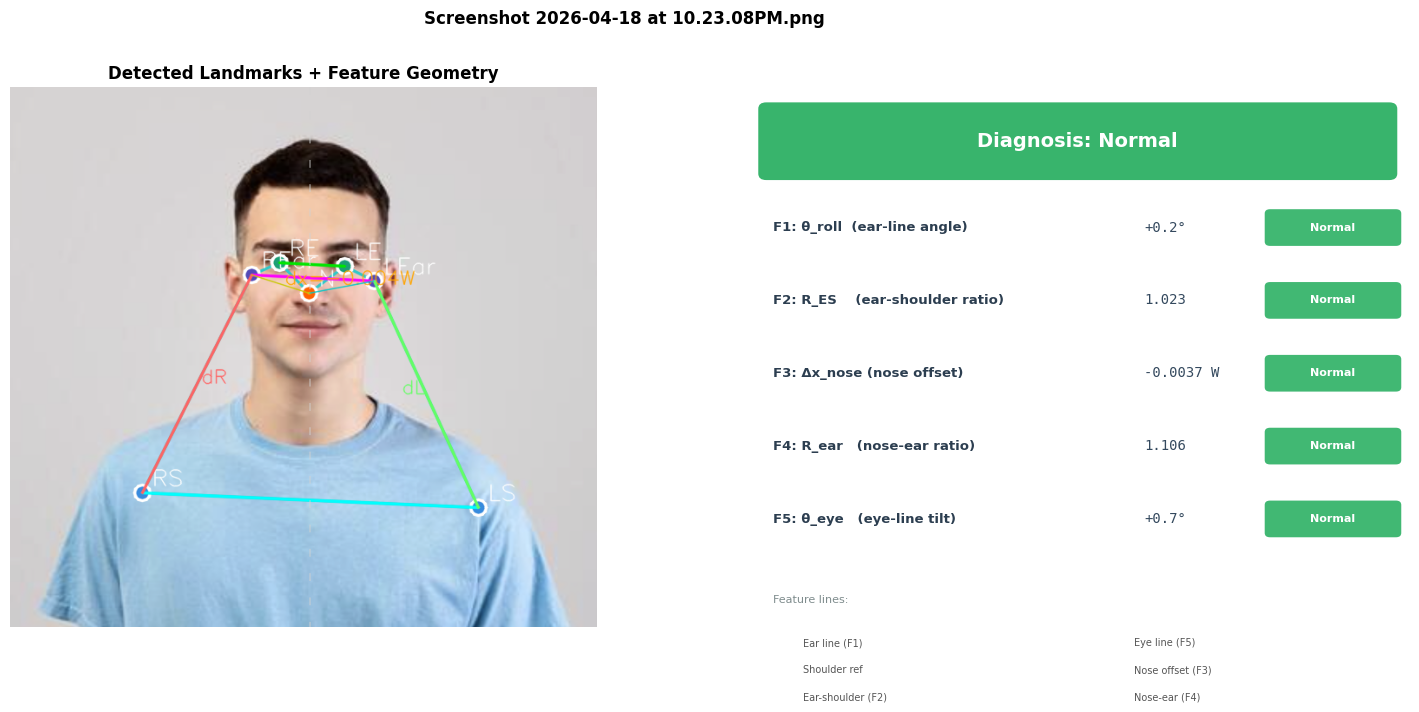


  File : Screenshot 2026-04-18 at 10.23.08PM.png
  Diagnosis : Normal
  ────────────────────────────────────────────────
  F1 θ_roll  =   +0.24°     [    Normal]
  F2 R_ES    =   1.023        [    Normal]
  F3 Δx_nose = -0.0037 W  [    Normal]
  F4 R_ear   =   1.106        [    Normal]
  F5 θ_eye   =   +0.68°     [    Normal]



In [16]:
# ─────────────────────────────────────────────────────────────
#  EDIT THIS PATH to your actual image
# ─────────────────────────────────────────────────────────────
IMAGE_PATH = '/kaggle/input/datasets/kuldipkmanvar/cervical-dystonia-images/Screenshot 2026-04-18 at 10.23.08PM.png'

result = analyse_image(
    image_path=IMAGE_PATH,
    model_path=MODEL_PATH,
    save_path='/kaggle/working/single_image_report.png',
    show=True,
)